In [1]:
import pandas as pd

In [4]:
# pd.read_csv('../Data/fruits.csv').head()   로 먼저 데이터 맞는지 확인
fruits = pd.read_csv('../Data/fruits.csv')
fruits.head()


,length,weight,name
0,25.4,242.0,apple
1,26.3,290.0,apple
2,26.5,340.0,apple
3,29.0,363.0,apple
4,29.0,430.0,apple


### Feature Set 과 Target Set 를 Numpy Array 로 변경

In [5]:
import numpy as np

#### 연습

In [21]:
# numpy 의 column stack 과 vstack
testA = np.array([1, 2, 3, 4])
testB = np.array([10, 20, 30, 40])

# 2개의 Array 를 묶어서 컬럼기반의 Array 로 만들기     zip() : 데이터를 한 번에 묶어줌.
combineA = [[i, j] for i, j in zip(testA, testB)]
print(np.array(combineA))

# 위가 예전 방식
print('-' * 50)

# numpy 에서 컬럼 기반 합치기
combineB = np.column_stack((testA, testB))
print(combineB)

print('-' * 50)

# numpy 에서 index 기반으로 합치기 : vstack
combineC = np.vstack((testA, testB))
print(combineC)


[[ 1 10]
 [ 2 20]
 [ 3 30]
 [ 4 40]]
--------------------------------------------------
[[ 1 10]
 [ 2 20]
 [ 3 30]
 [ 4 40]]
--------------------------------------------------
[[ 1  2  3  4]
 [10 20 30 40]]


In [22]:
# List Comprehension 개념
test1 = []
#list(range(1, 11)) # 이래도 되고

for i in range(1, 11):
    test1.append(i)    # 하나씩 숫자 늘려가면서 추가(append)

# 위를 아래 한 줄로 쓸 수 있음. 속도도 빠름.
test1 = [i for i in range(1, 11)]    # 인터프리터 방식이기에 위는 계속 2줄씩 읽고, 얜 한 번만 읽음.
test1

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

In [25]:
# fruit 의 feature
fruits_data = np.column_stack((fruits.length, fruits.weight))
fruits_data[:5]

array([[ 25.4, 242. ],
       [ 26.3, 290. ],
       [ 26.5, 340. ],
       [ 29. , 363. ],
       [ 29. , 430. ]])

In [26]:
fruits_data.shape

(49, 2)

In [32]:
# Target
fruits_target = np.array(fruits.name)
fruits_target[:5]       # head() 안 써짐 왜임?   ===> numpy 에서는 .head() 가 안 써짐. 슬라이싱 방식인 [:5] 만 사용 가능. pandas 에선 .head(), 슬라이싱 다 가능함.

array(['apple', 'apple', 'apple', 'apple', 'apple'], dtype=object)

In [33]:
from sklearn.model_selection import train_test_split

In [40]:
train_input, test_input, train_target, test_target = \
    train_test_split(
        fruits_data,
        fruits_target,
        random_state=42,
        stratify=fruits_target  # target 의 비율을 비슷하게 뽑아라
    )

In [41]:
# kNN 을 이용한 예측
from sklearn.neighbors import KNeighborsClassifier  # classifier 는 분류 때 씀

In [43]:
# 모델 만들기
kn = KNeighborsClassifier()   # n_neighbors = 5  (마우스 호버해도 나옴)

# 학습시키기
kn.fit(train_input, train_target)

# 검증하기
print(kn.score(train_input, train_target))
print(kn.score(test_input, test_target))

1.0
1.0


-----
#### 수상한 과일

In [47]:
# length 가 25cm 이고, weight 가 150g 인 과일은?
kn.predict([
    [25, 150]
])


array(['berry'], dtype=object)

#### 시각화

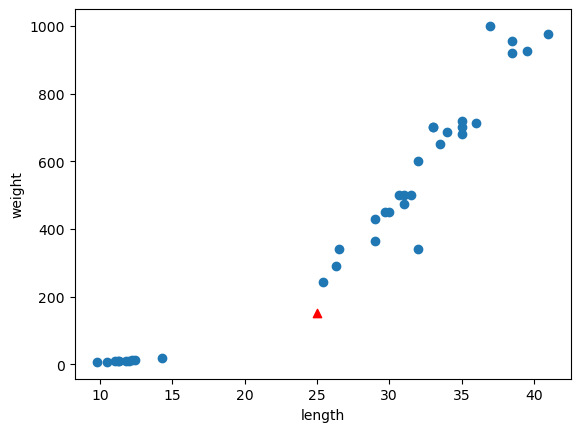

In [56]:
import matplotlib.pyplot as plt
plt.scatter(
    train_input[:,0],
    train_input[:,1]
)
plt.scatter(
    25, 
    150,
    marker='^',
    c='red'
)

plt.xlabel('length')
plt.ylabel('weight')

plt.show()

ㄴ knn 으로 했음에도 주변의 apple 로 나오지 않고 berry 로 출력한 모습.

#### 이웃을 출력

In [60]:
distances, indexes = kn.kneighbors([[25,150]])   # 두 개 나오는데 첫 번째 거는 거리, 두 번째 거는 이웃의 index 번호
# print(distances)
print(indexes)

[[11 20 13 22 15]]


In [62]:
# 이웃 indexes 에 해당하는 Feature 를 출력
train_input[indexes]  # 3개가 berry 로 추정, 2개가 apple 로 추정되기에 berry 로 나온 것.

array([[[ 25.4, 242. ],
        [ 14.3,  19.7],
        [ 12.4,  13.4],
        [ 12.2,  12.2],
        [ 26.3, 290. ]]])

In [63]:
# 이웃 indexes 에 해당하는 Target 을 출력
train_target[indexes]  # 3개가 berry 로 추정, 2개가 apple 로 추정되기에 berry 로 나온 것.

array([['apple', 'berry', 'berry', 'berry', 'apple']], dtype=object)

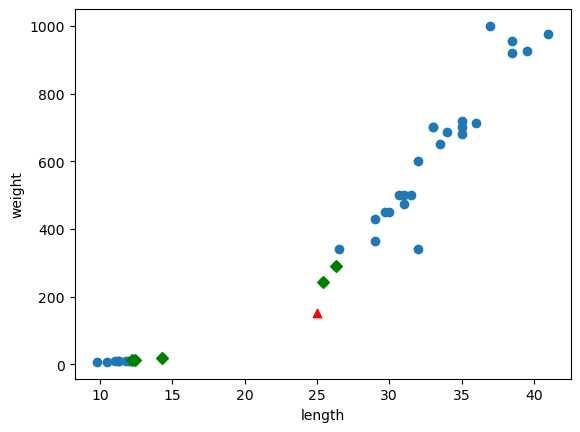

In [65]:
# 이웃의 위치를 출력
plt.scatter(
    train_input[:,0],
    train_input[:,1]
)
plt.scatter(
    25, 
    150,
    marker='^',
    c='red'
)
plt.scatter(
    train_input[indexes, 0],
    train_input[indexes, 1],
    marker='D',
    c='green'
)

plt.xlabel('length')
plt.ylabel('weight')

plt.show()

---- 
#### 기준을 맞추자 (중요)

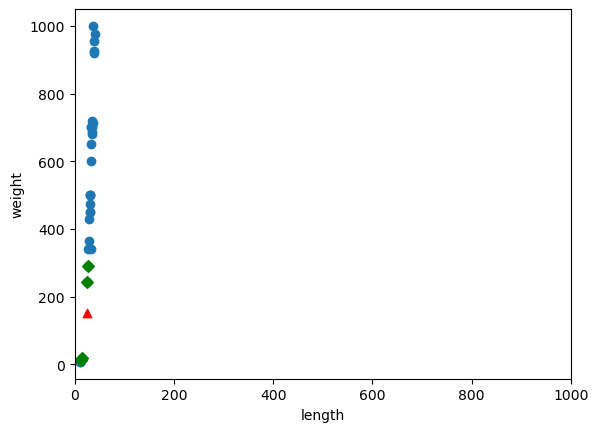

In [66]:
# 이웃의 위치를 출력
plt.scatter(
    train_input[:,0],
    train_input[:,1]
)
plt.scatter(
    25, 
    150,
    marker='^',
    c='red'
)
plt.scatter(
    train_input[indexes, 0],
    train_input[indexes, 1],
    marker='D',
    c='green'
)

plt.xlim(0, 1000)    # x 길이 바꾸기
plt.xlabel('length')
plt.ylabel('weight')

plt.show()

위의 그래프는 apple이 가까워 보였는데 여기서는 berry 가 가까움 : x, y 축 비율이 달랐기 때문
> data 가 Length 에는 거의 영향을 받지 않고 Weight 에서 영향을 많이 받음.
중요한 Feature 는 Weight

##### 표준화
단위가 다르면 표준화를 쓰고 단위가 같으면 정규화를 씀.

In [84]:
# length 와 weight 의 평균과 표준편차. => 기준은 train 으로
mean = np.mean(train_input, axis=0)    # axis 는 shape 해봤을 때 (23, 5) 라면 axis=0 은 23짜리, axis=1 은 5 짜리
mean

array([ 26.93333333, 441.98333333])

In [74]:
std = np.std(train_input, axis=0)      # 이렇게 구하고 판단하는 걸 표준화 라고 함   <-(비교)-> 정규화 : z점수가 0~1 사이로 나옴
std

array([ 10.09141549, 325.61300692])

##### train_data 를 표준점수(z점수) 로 변경
표준점수 = (Feature - 평균) / 표준편차

In [73]:
train_scaled = (train_input - mean) / std
train_scaled[:5]

array([[ 0.79935928,  0.85382543],
       [ 0.20479453, -0.24256812],
       [-1.54917151, -1.33066961],
       [ 0.37325454,  0.17817675],
       [-1.55908092, -1.32729137]])

##### sklearn 을 이용

In [75]:
from sklearn.preprocessing import StandardScaler   # 표준화 틀

In [76]:
scaler = StandardScaler()
scaler.fit(train_input)

,copy,True
,with_mean,True
,with_std,True


In [78]:
train_scaled2 = scaler.transform(train_input)   # input을 학습한대로 바꿔라
train_scaled2[:5]

array([[ 0.79935928,  0.85382543],
       [ 0.20479453, -0.24256812],
       [-1.54917151, -1.33066961],
       [ 0.37325454,  0.17817675],
       [-1.55908092, -1.32729137]])

In [81]:
# 위 두 개의 sklearn 을 더 간단하게
train_scaled3 = scaler.fit_transform(train_input)
train_scaled3[:5]

array([[ 0.79935928,  0.85382543],
       [ 0.20479453, -0.24256812],
       [-1.54917151, -1.33066961],
       [ 0.37325454,  0.17817675],
       [-1.55908092, -1.32729137]])

#### 전처리 데이터로 모델 훈련하기

In [83]:
# 예측할 데이터도 표준점수 변경이 필요
new = ([25, 150] - mean) / std
new

array([-0.19158198, -0.89671889])

#### kNN

In [85]:
kn.fit(train_scaled3, train_target)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [90]:
test_scaled = (test_input - mean) / std
print(kn.score(train_scaled3, train_target))   # fit 하고 score 하면 1만 나오는데 왜 하는지 > 과대인지 과소인지 확인하려고. 나중에 데이터 다르게 하면 1 안 나올수도 있음.
print(kn.score(test_scaled, test_target))

1.0
1.0


In [88]:
# 예측
kn.predict([new])

array(['apple'], dtype=object)

#### 시각화

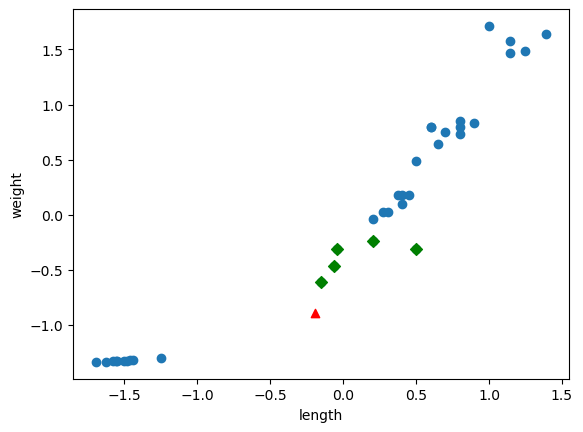

In [89]:
# 이웃의 위치를 출력
distances, indexes = kn.kneighbors([new])

plt.scatter(
    train_scaled3[:,0],
    train_scaled3[:,1]
)
plt.scatter(
    new[0], 
    new[1],
    marker='^',
    c='red'
)
plt.scatter(
    train_scaled3[indexes, 0],
    train_scaled3[indexes, 1],
    marker='D',
    c='green'
)

plt.xlabel('length')
plt.ylabel('weight')

plt.show()